Final Project - MLSP

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import librosa
import scipy.signal as signal


In [103]:
def process_video(video_path):

    video_data=cv2.VideoCapture(video_path)
    video_w=int(video_data.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_h=int(video_data.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_frames=int(video_data.get(cv2.CAP_PROP_FRAME_COUNT))
    fps=int(video_data.get(cv2.CAP_PROP_FPS))
    new_w= 80
    new_h= int(new_w*video_h/video_w)
    print(new_w,new_h,fps)
    frames=[]

    #We use this method instead of frame count becuase some people report issues.
    #https://github.com/opencv/opencv/issues/16821
    while video_data.isOpened():
        ret, frame= video_data.read()
        if not ret:
            break
        ds_frame=cv2.resize(frame,(new_w,new_h))
        gray=cv2.cvtColor(ds_frame,cv2.COLOR_BGR2GRAY)
        frames.append(gray.flatten(order="F"))

    X=np.array(frames).T

    return X, new_w, new_h

def nnmf(X, k, h_init=None, n_iter=200):

    M, N = X.shape

    if h_init is None:
        h = np.random.rand(k, N)
    else:
        h = h_init

    w = np.random.rand(M, k)
    eps = 1e-5
    for i in range(n_iter):
        w = w * ((X / (w @ h + eps) @ h.T) / (np.sum(h, axis=1) + eps))
        h = h * ((w.T @ (X / (w @ h + eps))) / (np.sum(w, axis=0)[:, None] + eps))
        scale = h.sum(axis=1) + eps
        h = h / scale[:, None]
        w = w * scale[None, :]
    return w, h

def reconstruction_error(X, w, h):
    # KL divergence — since that is where nmmf update rules come from 

    WH = w @ h + 1e-9
    return np.sum(X * np.log((X + 1e-9) / WH) - X + WH)


def choose_best_nmmf(X,k, h_init=None, n_iter=10):
    results=[]
    for i in range(n_iter):
        w,h=nnmf(X,k,h_init)
        results.append((reconstruction_error(X,w,h),w,h))

    results.sort(key=lambda x: x[0])
    return results[0]


def process_activation(h,threshold=0.5):
    # Step 1: Select best row by highest peak
    peak_per_row = h.max(axis=1)
    best_idx = np.argmax(peak_per_row)
    best_row = h[best_idx, :].copy()

    # Step 2: Gate using 50% of the (max - min) range
    # row_min=best_row.min()
    # row_max=best_row.max()
    # threshold_val = row_min + threshold * (row_max - row_min)
    # best_row[best_row < threshold_val] = 0

    # # Step 3: Renormalize to [0, 1]
    # # row_max_gated = best_row.max() + 1e-9
    # best_row = best_row / best_row.sum()

    return best_row

def process_audio(audio_path):


    x, sr=librosa.load(audio_path,sr=None,mono=True)
    n_fft, hop_length = 512, 256
    D = librosa.stft(x, n_fft=n_fft, hop_length=hop_length)

    
    # Magnitude and log
    S = np.abs(D)
    # S_log = np.log1p(S)

    return S

def upscale_activation(h,D):
    audio_len=D.shape[1]
    h_len=h.shape[0]
    new_x=np.linspace(0,h_len,audio_len)
    h_interp=np.interp(new_x,np.arange(h_len),h)
    return h_interp
    
    

80 45 30


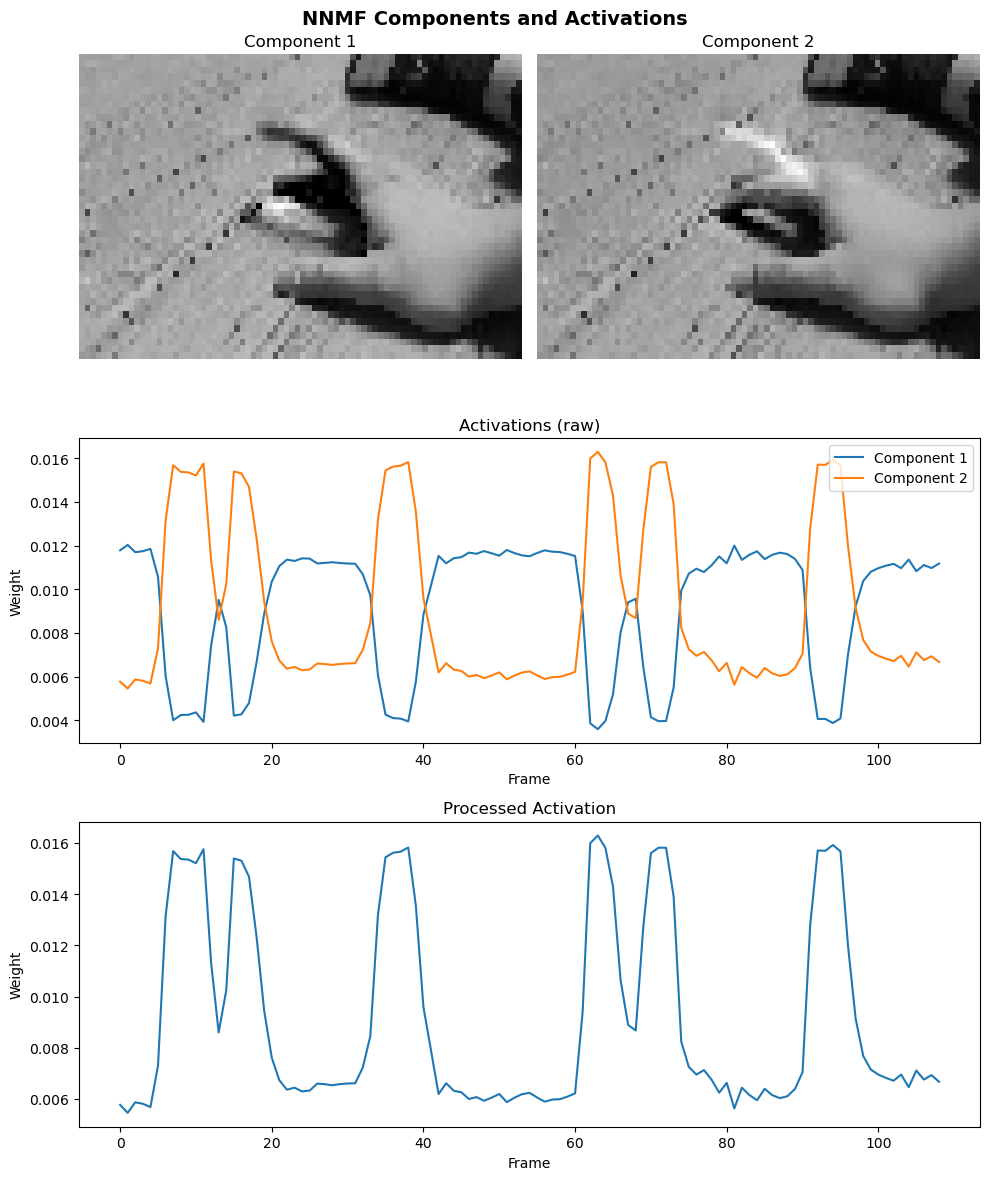

In [104]:
X, new_w, new_h = process_video("hit.MOV")

k = 2

error, W, H = choose_best_nmmf(X, k)
processed_h = process_activation(H,threshold=.5)

fig = plt.figure(figsize=(5 * k, 12))
fig.suptitle("NNMF Components and Activations", fontsize=14, fontweight="bold")

for i in range(k):
    ax = fig.add_subplot(3, k, i + 1)
    component_img = W[:, i].reshape(new_h, new_w, order="F")
    ax.imshow(component_img, cmap="gray", aspect="auto")
    ax.set_title(f"Component {i+1}")
    ax.axis("off")

ax_act = fig.add_subplot(3, 1, 2)
for i in range(k):
    ax_act.plot(H[i], label=f"Component {i+1}")
ax_act.set_title("Activations (raw)")
ax_act.set_xlabel("Frame")
ax_act.set_ylabel("Weight")
ax_act.legend()

ax_proc = fig.add_subplot(3, 1, 3)
ax_proc.plot(processed_h)
ax_proc.set_title("Processed Activation")
ax_proc.set_xlabel("Frame")
ax_proc.set_ylabel("Weight")

plt.tight_layout()
plt.show()


In [ ]:
D=process_audio("test_audio.wav")

h_init=upscale_activation(processed_h,D)
pad=np.random.rand(1,D.shape[1])
h_init=np.vstack((pad,h_init,pad))

print(h_init.shape, D.shape)

ee=choose_best_nmmf(D,k=3,h_init=h_init)





    

(3, 348) (257, 348)


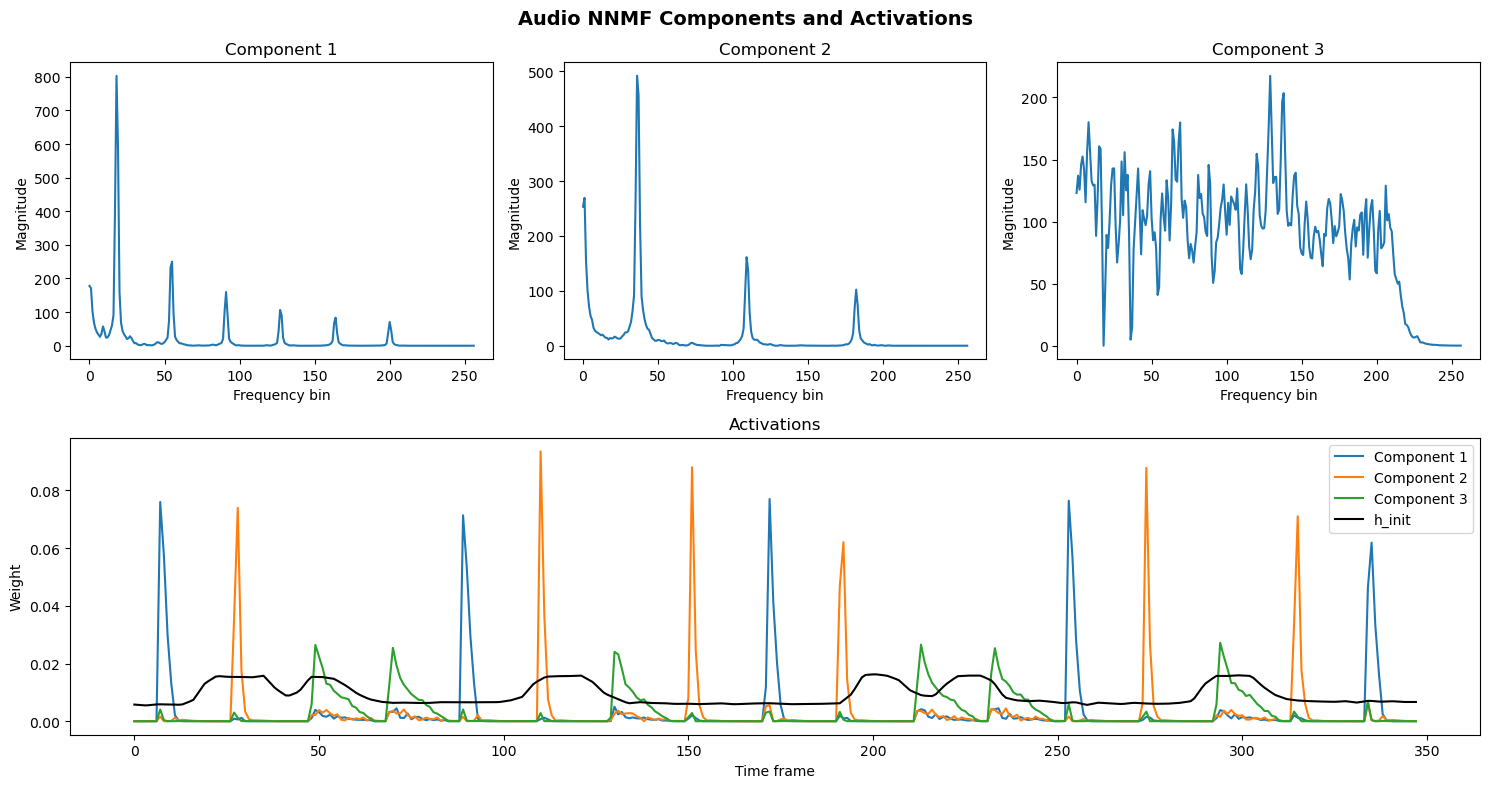

In [111]:
W_a, H_a = audio_nmmf
k_a = W_a.shape[1]

fig = plt.figure(figsize=(5 * k_a, 8))
fig.suptitle("Audio NNMF Components and Activations", fontsize=14, fontweight="bold")

for i in range(k_a):
    ax = fig.add_subplot(2, k_a, i + 1)
    ax.plot(W_a[:, i])
    ax.set_title(f"Component {i+1}")
    ax.set_xlabel("Frequency bin")
    ax.set_ylabel("Magnitude")

ax_act = fig.add_subplot(2, 1, 2)
for i in range(k_a):
    ax_act.plot(H_a[i,:], label=f"Component {i+1}")
ax_act.plot(h_init[1,:], label="h_init", color="black")
ax_act.set_title("Activations")
ax_act.set_xlabel("Time frame")
ax_act.set_ylabel("Weight")
ax_act.legend()

plt.tight_layout()
plt.show()
